1. Import and Reading CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('../cardio_train.csv', sep=';')
df.to_csv("../cardio_train_clean.csv",index=False)
df
df=pd.read_csv('../cardio_train_clean.csv')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


2. Checking Total number of null values

In [3]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [9]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [11]:
df = df.drop("id", axis=1)
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [13]:
print('Before Duplicate:',df.duplicated().sum())

Before Duplicate: 24


In [19]:
df.drop_duplicates(inplace=True)
print('After Duplicate:', df.duplicated().sum())

After Duplicate: 0


3. Converting age from days to years

In [11]:
df['age_years'] = (df['age'] / 365).round(1)
df['age_years']

0        50.4
1        55.4
2        51.7
3        48.3
4        47.9
         ... 
69995    52.7
69996    61.9
69997    52.2
69998    61.5
69999    56.3
Name: age_years, Length: 70000, dtype: float64

4. Counting negative values and than removing rows having those not possible values

In [13]:
# --- Age ---
print("Negative ages:", (df['age_years'] < 0).sum())
df = df[(df['age_years'] > 0) & (df['age_years'] < 150)]

# --- Gender ---
print("Invalid gender values:", (~df['gender'].isin([1,2])).sum())
df = df[df['gender'].isin([1,2])]

# --- Height ---
print("Invalid heights:", ((df['height'] < 80) | (df['height'] > 300)).sum())
df = df[(df['height'] >= 80) & (df['height'] <= 260)]

# --- Weight ---
print("Invalid weights:", ((df['weight'] < 5) | (df['weight'] > 200)).sum())
df = df[(df['weight'] >= 10) & (df['weight'] <= 200)]

# --- Systolic BP ---
print("Invalid ap_hi values:", ((df['ap_hi'] < 50) | (df['ap_hi'] > 300)).sum())
df = df[(df['ap_hi'] >= 50) & (df['ap_hi'] <= 300)]

# --- Diastolic BP ---
print("Invalid ap_lo values:", ((df['ap_lo'] < 20) | (df['ap_lo'] > 200)).sum())
df = df[(df['ap_lo'] >= 20) & (df['ap_lo'] <= 200)]

# --- Cholesterol ---
print("Invalid cholesterol values:", (~df['cholesterol'].isin([1,2,3])).sum())
df = df[df['cholesterol'].isin([1,2,3])]

# --- Glucose ---
print("Invalid glucose values:", (~df['gluc'].isin([1,2,3])).sum())
df = df[df['gluc'].isin([1,2,3])]

# --- Smoking ---
print("Invalid smoke values:", (~df['smoke'].isin([0,1])).sum())
df = df[df['smoke'].isin([0,1])]

# --- Alcohol ---
print("Invalid alco values:", (~df['alco'].isin([0,1])).sum())
df = df[df['alco'].isin([0,1])]

# --- Physical activity ---
print("Invalid active values:", (~df['active'].isin([0,1])).sum())
df = df[df['active'].isin([0,1])]


Negative ages: 0
Invalid gender values: 0
Invalid heights: 22
Invalid weights: 0
Invalid ap_hi values: 227
Invalid ap_lo values: 976
Invalid cholesterol values: 0
Invalid glucose values: 0
Invalid smoke values: 0
Invalid alco values: 0
Invalid active values: 0


5. Adding BMI COL

In [15]:
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.967120
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.927679
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.7,23.507805
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.3,28.710479
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.9,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52.7,26.927438
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61.9,50.472681
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52.2,31.353579
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61.5,27.099251


6. Male and Female Counts

In [17]:
df.groupby('cardio')['gender'].value_counts()

cardio  gender
0       1         22742
        2         11992
1       1         22050
        2         11991
Name: count, dtype: int64

7. Correlation Matrix

In [19]:
corr_matrix=df[['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']].corr()
corr_matrix

,age_years,height,weight,ap_hi,ap_lo
age_years,1.000000,-0.083520,0.054623,0.208499,0.152119
height,-0.083520,1.000000,0.297788,0.017906,0.034816
weight,0.054623,0.297788,1.000000,0.269276,0.248086
ap_hi,0.208499,0.017906,0.269276,1.000000,0.694392
ap_lo,0.152119,0.034816,0.248086,0.694392,1.000000


8. Graph of age vs cardio people

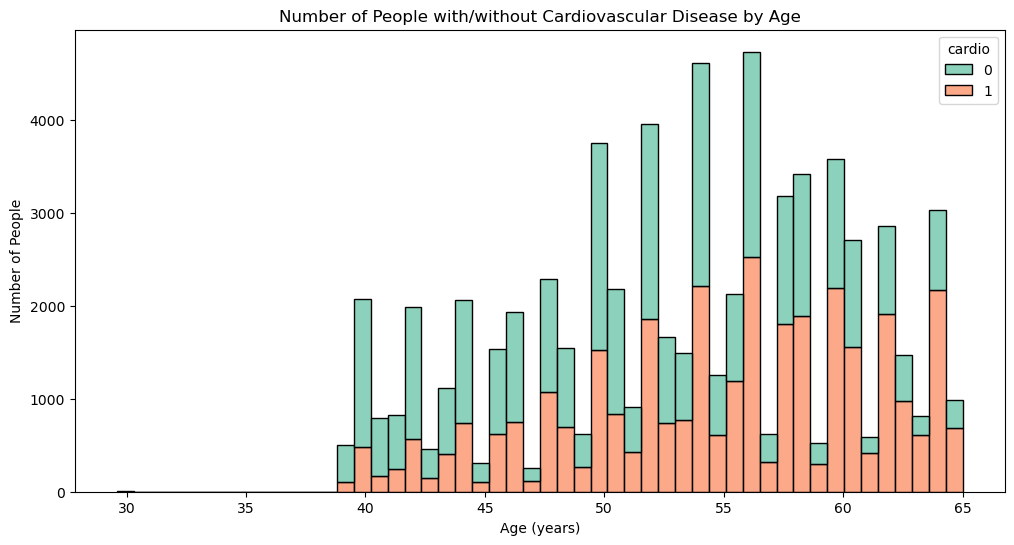

In [21]:
# with stack, lower will be stacked on higher, like if cardio will be high than it will come below the bar of lower, so both can be visible properly
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='age_years', hue='cardio', multiple='stack', bins=50, palette='Set2')

plt.title('Number of People with/without Cardiovascular Disease by Age')
plt.xlabel('Age (years)')
plt.ylabel('Number of People')
plt.show()

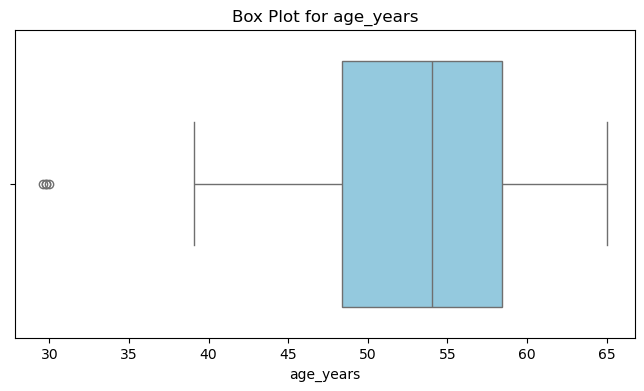


Column: age_years
IQR lower bound = 33.40, upper bound = 73.40
Number of outliers: 4
       age_years
6219        29.8
22343       29.6
30666       29.8
55905       30.0


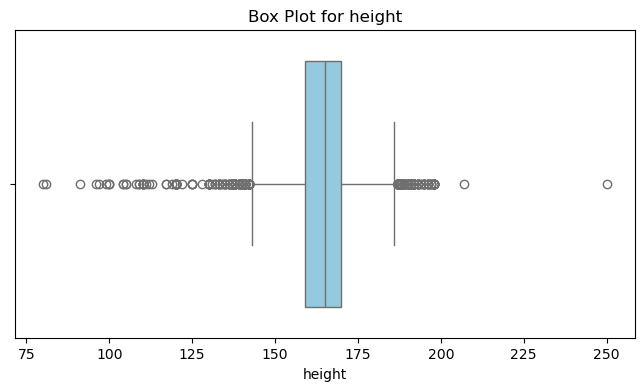


Column: height
IQR lower bound = 142.50, upper bound = 186.50
Number of outliers: 487
      height
62       187
76       188
249      142
781      141
1027     195


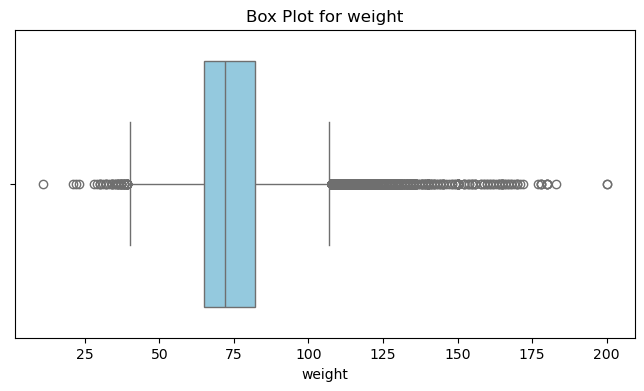


Column: weight
IQR lower bound = 39.50, upper bound = 107.50
Number of outliers: 1747
     weight
15    112.0
62    115.0
83    110.0
196   108.0
267   115.0


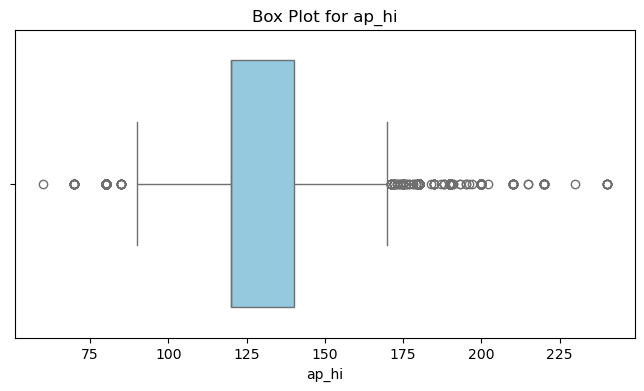


Column: ap_hi
IQR lower bound = 90.00, upper bound = 170.00
Number of outliers: 1069
     ap_hi
59     180
61     180
101    190
209     80
230    180


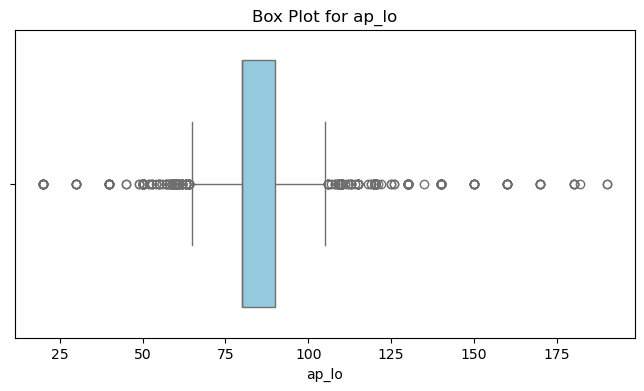


Column: ap_lo
IQR lower bound = 65.00, upper bound = 105.00
Number of outliers: 3618
    ap_lo
4      60
9      60
23     60
43     60
50     60


In [23]:
numeric_cols = ["age_years", "height", "weight", "ap_hi", "ap_lo"]


# outlier finding function
def detect_outliers_iqr(data, column):
    # Gives the value at the 25% point of the distribution.
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper


# Plot box plots & outliers will be printed here
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Box Plot for {col}')
    plt.show()
    
    outliers, low, high = detect_outliers_iqr(df, col)
    print(f"\nColumn: {col}")
    print(f"IQR lower bound = {low:.2f}, upper bound = {high:.2f}")
    print(f"Number of outliers: {len(outliers)}")
    print(outliers[[col]].head())


In [25]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.967120
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.927679
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.7,23.507805
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.3,28.710479
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.9,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52.7,26.927438
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61.9,50.472681
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52.2,31.353579
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61.5,27.099251


In [27]:
df.to_csv("../data/cardio_train_clean.csv",index=False)